✓ Model trained


,Threshold,Alerts,Precision,Recall,F1
0,0.01,93,0.526882,0.875000,0.657718
1,0.02,72,0.666667,0.857143,0.750000
4,0.05,59,0.779661,0.821429,0.800000
9,0.10,54,0.851852,0.821429,0.836364
19,0.20,52,0.846154,0.785714,0.814815
29,0.30,51,0.862745,0.785714,0.822430
39,0.40,49,0.897959,0.785714,0.838095
49,0.50,47,0.914894,0.767857,0.834951
59,0.60,43,0.976744,0.750000,0.848485
79,0.80,43,0.976744,0.750000,0.848485


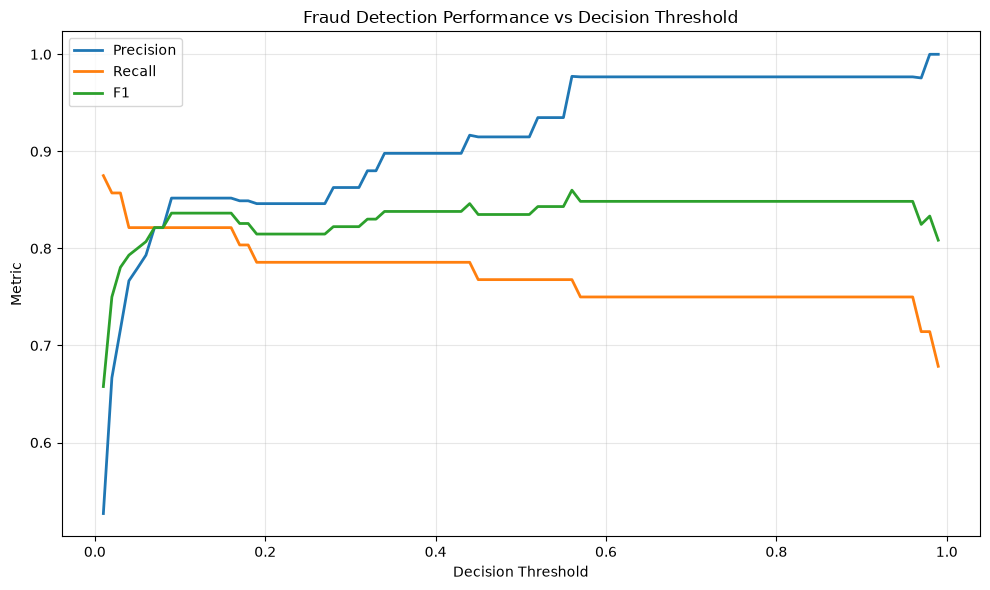

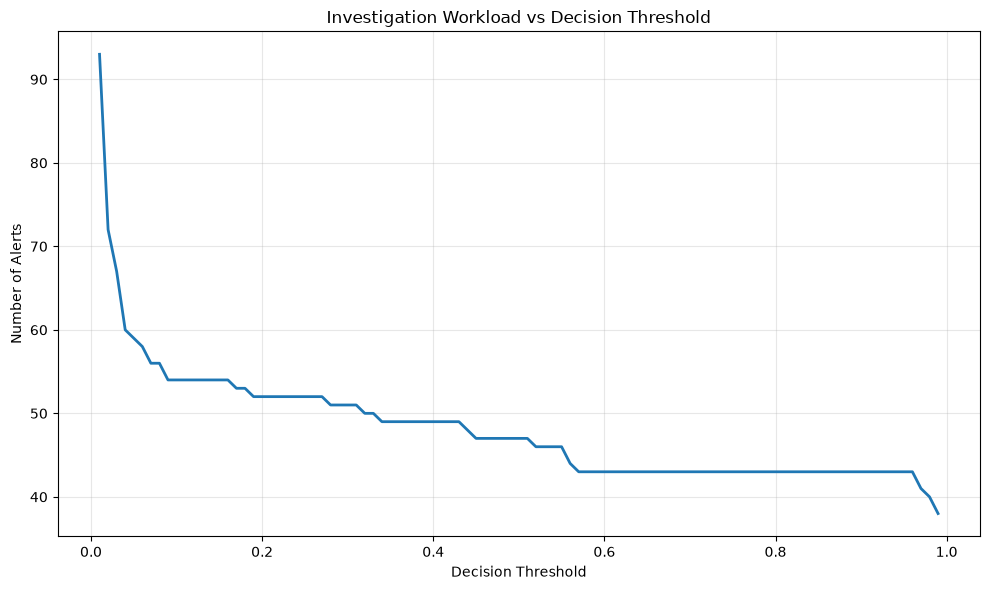


BEST F1 THRESHOLD
Threshold : 0.56
Precision : 0.9773
Recall    : 0.7679
F1        : 0.8600
Alerts    : 44

INVESTIGATION CAPACITY ANALYSIS


,Investigation Capacity,Fraud Captured,Precision,Recall
0,10,10,1.000,0.178571
1,20,20,1.000,0.357143
2,30,30,1.000,0.535714
3,50,44,0.880,0.785714
4,100,49,0.490,0.875000
5,200,50,0.250,0.892857
6,500,51,0.102,0.910714



✓ Threshold results saved.
✓ Capacity results saved.

PHASE 5 COMPLETE


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# PHASE 5 — THRESHOLD ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")

df = pd.read_csv(DATA_PATH)

df = df.sort_values("Time").reset_index(drop=True)


# ============================================================
# 2. TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:validation_end].copy()
test = df.iloc[validation_end:].copy()


# ============================================================
# 3. FEATURES
# ============================================================

TARGET = "Class"

FEATURES = [
    c for c in df.columns
    if c != TARGET
]

X_train = train[FEATURES]
y_train = train[TARGET]

X_validation = validation[FEATURES]
y_validation = validation[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


# ============================================================
# 4. CLASS WEIGHT
# ============================================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive


# ============================================================
# 5. TRAIN MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

print("✓ Model trained")


# ============================================================
# 6. PROBABILITIES
# ============================================================

validation_prob = model.predict_proba(
    X_validation
)[:, 1]

test_prob = model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 7. THRESHOLD GRID
# ============================================================

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

results = []


for threshold in thresholds:

    validation_pred = (
        validation_prob >= threshold
    ).astype(int)

    results.append({

        "Threshold": threshold,

        "Alerts": int(
            validation_pred.sum()
        ),

        "Precision": precision_score(
            y_validation,
            validation_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_validation,
            validation_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_validation,
            validation_pred,
            zero_division=0
        )
    })


threshold_results = pd.DataFrame(results)


# ============================================================
# 8. DISPLAY USEFUL THRESHOLDS
# ============================================================

selected_thresholds = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

display(
    threshold_results[
        threshold_results["Threshold"].isin(
            selected_thresholds
        )
    ]
)


# ============================================================
# 9. PRECISION / RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1",
    linewidth=2
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric")

plt.title(
    "Fraud Detection Performance vs Decision Threshold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 10. ALERT VOLUME
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Alerts"],
    linewidth=2
)

plt.xlabel("Decision Threshold")
plt.ylabel("Number of Alerts")

plt.title(
    "Investigation Workload vs Decision Threshold"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 11. FIND BEST F1 THRESHOLD
# ============================================================

best_f1_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST F1 THRESHOLD")
print("=" * 70)

print(
    f"Threshold : "
    f"{best_f1_row['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{best_f1_row['Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_f1_row['Recall']:.4f}"
)

print(
    f"F1        : "
    f"{best_f1_row['F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(best_f1_row['Alerts'])}"
)


# ============================================================
# 12. INVESTIGATION CAPACITY
# ============================================================

capacity_levels = [
    10,
    20,
    30,
    50,
    100,
    200,
    500
]

capacity_results = []

for capacity in capacity_levels:

    # Select the highest-risk transactions
    # up to the investigation capacity.

    ranking = np.argsort(
        validation_prob
    )[::-1]

    selected_indices = ranking[:capacity]

    y_selected = y_validation.iloc[
        selected_indices
    ]

    fraud_captured = int(
        y_selected.sum()
    )

    precision = (
        fraud_captured / capacity
        if capacity > 0
        else 0
    )

    total_fraud = int(
        y_validation.sum()
    )

    recall = (
        fraud_captured / total_fraud
        if total_fraud > 0
        else 0
    )

    capacity_results.append({

        "Investigation Capacity": capacity,

        "Fraud Captured": fraud_captured,

        "Precision": precision,

        "Recall": recall
    })


capacity_results = pd.DataFrame(
    capacity_results
)

print("\n" + "=" * 70)
print("INVESTIGATION CAPACITY ANALYSIS")
print("=" * 70)

display(capacity_results)


# ============================================================
# 13. SAVE RESULTS
# ============================================================

threshold_results.to_csv(
    "../reports/threshold_analysis.csv",
    index=False
)

capacity_results.to_csv(
    "../reports/investigation_capacity.csv",
    index=False
)

print("\n✓ Threshold results saved.")
print("✓ Capacity results saved.")


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("PHASE 5 COMPLETE")
print("=" * 70)